In [21]:
%matplotlib inline
import warnings, os, json, time, math
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ML models 
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Hyperparameter tuning 
import optuna

# Feature importance / interpretability 
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', font_scale=1.05)

BLUE, ORANGE, RED, GREEN, PURPLE, TEAL = '#1a6bff', '#f59e0b', '#ef4444', '#22c55e', '#8b5cf6', '#06b6d4'
MODEL_COLORS = {
    'LightGBM':         BLUE,
    'XGBoost':          ORANGE,
    'RandomForest':     GREEN,
    'GradientBoosting': PURPLE,
    'Ridge':            '#94a3b8',
    'ElasticNet':       '#6b7280',
    'Ensemble':         RED,
}

SEED = 42
np.random.seed(SEED)

print(f'LightGBM  {lgb.__version__}')
print(f'XGBoost   {xgb.__version__}')
print(f'Optuna    {optuna.__version__}')
print(f'SHAP      {shap.__version__}')


LightGBM  4.6.0
XGBoost   3.2.0
Optuna    4.9.0
SHAP      0.51.0


In [22]:
ROOT   = Path('../').resolve()
DATA   = ROOT / 'data'
MASTER = DATA / 'master'
MODELS = ROOT / 'models';  MODELS.mkdir(exist_ok=True)
PLOTS  = DATA / 'plots';   PLOTS.mkdir(parents=True, exist_ok=True)
REPORTS = ROOT / 'reports'; REPORTS.mkdir(exist_ok=True)

# V4 dataset builder outputs (Zentra_crowd_predictor_dataV4.ipynb, Section 14 export)
MASTER_CSV    = MASTER / 'zentra_training_master.csv'   # single table, all survey dates
LIVE_GRID_CSV = MASTER / 'zentra_live_grid_snapshot.csv'  # "right now" feature rows, every H3 cell
MANIFEST_CSV  = MASTER / 'feature_manifest_v2.csv'           # per-feature dtype / null% / correlation
POI_CSV       = MASTER / 'poi_hex_counts.csv'
GRID_CSV      = MASTER / 'manhattan_grid_h3.csv'

# Artefacts this notebook derives itself 
TRAIN_CSV  = MASTER / 'zentra_train.csv'
VAL_CSV    = MASTER / 'zentra_val.csv'

VAL_FRACTION = 0.2  # most recent 20% of survey dates held out for validation

for p in [MASTER_CSV, LIVE_GRID_CSV, MANIFEST_CSV]:
    if not p.exists():
        print(f'WARNING: {p.name} not found — notebook first.')
    else:
        print(f'  Found: {p.name}')


  Found: zentra_training_master.csv
  Found: zentra_live_grid_snapshot.csv
  Found: feature_manifest_v2.csv


## 1 · Load V4 Dataset — Build Train / Val Splits

The V4 dataset builder outputs a single master table (one row per
`location_id` x `period` x `survey_date`) rather than a pre-split train/val
pair. We build the split here ourselves: a **time-based 80/20 split** on
unique `survey_date` values, so validation always covers the most recent
survey date(s) — same principle as V3, just performed in this notebook
instead of upstream.


In [ ]:
master_df = pd.read_csv(MASTER_CSV, parse_dates=['survey_date'])

_dates = sorted(master_df['survey_date'].unique())
_split_i = max(1, int(len(_dates) * (1 - VAL_FRACTION)))
train_dates, val_dates = _dates[:_split_i], _dates[_split_i:]

train_df = master_df[master_df['survey_date'].isin(train_dates)].copy()
val_df   = master_df[master_df['survey_date'].isin(val_dates)].copy()

train_df.to_csv(TRAIN_CSV, index=False)
val_df.to_csv(VAL_CSV, index=False)

print(f'Survey dates total: {len(_dates)}  ->  train: {len(train_dates)}  val: {len(val_dates)}')
print(f'Train : {train_df.shape[0]:,} rows  '
      f'({train_df["survey_date"].min().date()} → {train_df["survey_date"].max().date()})')
print(f'Val   : {val_df.shape[0]:,} rows  '
      f'({val_df["survey_date"].min().date()} → {val_df["survey_date"].max().date()})')
print(f'Locations (train): {train_df["location_id"].nunique()}')
print(f'H3 cells  (train): {train_df["h3_cell"].nunique()}')
print()
print(train_df['pedestrians'].describe().rename('pedestrians (train)').to_frame().T)

# Distribution-shift sanity check 
# NYC pedestrian counts crashed in 2020 (COVID) and the post-2021 "recovery"
# settled at a permanently lower baseline than 2007-2019. Because the time-
# based split puts 2022-2025 entirely in validation, train and val are drawn
# from two different foot-traffic regimes - this alone can produce negative
# R² for any model that learns a pre-COVID baseline level, independent of
# tuning. Surfacing it here so it's checked before blaming the models.
_yearly = master_df.groupby(master_df['survey_date'].dt.year)['pedestrians'].mean()
print('\nMean pedestrians by year (watch for a pre/post-2020 regime shift):')
print(_yearly.round(0).astype(int).to_string())
print(f"\nTrain mean: {train_df['pedestrians'].mean():.0f}  |  Val mean: {val_df['pedestrians'].mean():.0f}  "
      f"({(1 - val_df['pedestrians'].mean() / train_df['pedestrians'].mean()) * 100:.1f}% lower in val)")


Survey dates total: 36  ->  train: 28  val: 8
Train : 3,948 rows  (2007-05-15 → 2021-10-15)
Val   : 1,194 rows  (2022-05-15 → 2025-10-15)
Locations (train): 36
H3 cells  (train): 30

                        count      mean       std    min       25%       50%  \
pedestrians (train) 3948.0000 7138.5296 6088.3275 0.0000 2771.5000 5259.0000   

                          75%        max  
pedestrians (train) 9680.7500 50827.0000  

Mean pedestrians by year (watch for a pre/post-2020 regime shift):
survey_date
2007    6711
2008    7824
2009    7102
2010    7117
2011    7277
2012    7022
2013    7814
2014    7513
2015    8029
2016    8143
2017    7746
2018    7865
2019    7664
2020    1806
2021    3620
2022    5486
2023    5608
2024    6021
2025    5751

Train mean: 7139  |  Val mean: 5717  (19.9% lower in val)


In [24]:
# Build feature metadata directly from the V4 feature manifest (no separate
# JSON file expected upstream - dataV4 only writes feature_manifest_v2.csv).

def assign_group(col):
    """Defined here (not just in Section 2) so it's available for the manifest
    grouping below as well as the later reporting cells."""
    for prefix, grp in [('tlc_', 'mobility'), ('mta_', 'mobility'), ('citibike_', 'mobility'),
                         ('poi_', 'poi'), ('event_', 'events'), ('avg_temp', 'weather'),
                         ('precip', 'weather'), ('avg_wind', 'weather'),
                         ('month_', 'temporal'), ('dow_', 'temporal'), ('doy_', 'temporal'),
                         ('period_', 'temporal'), ('is_', 'calendar'),
                         ('ped_lag', 'lag'), ('score_lag', 'lag'), ('ped_yoy', 'lag'),
                         ('ped_roll', 'rolling'), ('ped_mom', 'rolling'),
                         ('hist_', 'historical'), ('loc_', 'historical'),
                         ('_nb_', 'spatial_nb'), ('_ratio', 'poi_ratio'),
                         ('sunrise', 'sunlight'), ('sunset', 'sunlight'), ('day_length', 'sunlight')]:
        if col.startswith(prefix) or prefix in col:
            return grp
    if col.endswith('_missing'):
        return 'missing_flags'
    return 'other'

feat_meta = {}
if MANIFEST_CSV.exists():
    manifest_df = pd.read_csv(MANIFEST_CSV)
    for _, row in manifest_df.iterrows():
        feat_meta[row['feature']] = {
            'dtype': row.get('dtype'),
            'null_pct': row.get('null_pct'),
            'corr_with_log_pedestrians': row.get('corr_with_log_pedestrians'),
            'group': assign_group(row['feature']),
        }
    print(f'Feature metadata built from manifest: {len(feat_meta)} features')
    groups = {}
    for feat, info in feat_meta.items():
        groups.setdefault(info['group'], []).append(feat)
    for g, cols in sorted(groups.items()):
        print(f'  {g:<22}: {len(cols):>3} features')
else:
    print('No feature_manifest_v2.csv found - feat_meta stays empty; Section 2 will '
          'fall back to pattern-matching for groups, which works fine on its own.')

dataset_stats = {
    'target_stats': {
        'log_pedestrians_mean': float(train_df['log_pedestrians'].mean()),
        'log_pedestrians_std':  float(train_df['log_pedestrians'].std()),
        'pedestrians_mean':     float(train_df['pedestrians'].mean()),
        'pedestrians_std':      float(train_df['pedestrians'].std()),
    },
    'row_count': int(len(train_df)),
}
print(f"\nDataset statistics. Target log_ped mean={dataset_stats['target_stats']['log_pedestrians_mean']:.3f}")


Feature metadata built from manifest: 79 features
  calendar              :   4 features
  events                :   3 features
  lag                   :   5 features
  mobility              :  23 features
  other                 :  13 features
  poi                   :  17 features
  poi_ratio             :   1 features
  rolling               :   3 features
  sunlight              :   3 features
  temporal              :   4 features
  weather               :   3 features

Dataset statistics. Target log_ped mean=8.509


## 2 · Feature Preparation & Preprocessing

We define the exact feature set used for every model in the comparison, then
build the numpy arrays for training. Key decisions:

- **Target**: `log_pedestrians` (log₁ₑ(pedestrians + 1)) — log-transforms the
  right-skewed pedestrian count distribution into an approximately normal signal,
  which is better-behaved for regression.
- **Index / meta columns** are excluded from the feature matrix.
- **Lag and rolling features** from Section 16 are included in training but
  zeroed out at inference time (the metadata JSON flags this).
- `_missing` indicator flags are kept — they carry information about which
  proxy data sources were unavailable for a given cell/date.


In [25]:
INDEX_COLS = [
    'location_id', 'h3_cell', 'lat', 'lon', 'description',
    'survey_date', 'year', 'month', 'season', 'period',
]
TARGET     = 'log_pedestrians'
TARGET_RAW = 'pedestrians'
DROP_COLS  = INDEX_COLS + [TARGET_RAW, TARGET,
                           'crowd_score_true', 'crowd_score_proxy', 'crowd_score',
                           'ped_score']

# The V4 dataset builder's missing-indicator step runs twice upstream,
# producing exact-duplicate `*_missing_missing` columns alongside the
# real `*_missing` flags (confirmed identical, all-zero in this dataset).
# Drop them here rather than re-running the upstream builder.
DUPLICATE_MISSING_COLS = [c for c in train_df.columns if c.endswith('_missing_missing')]
if DUPLICATE_MISSING_COLS:
    print(f'Dropping {len(DUPLICATE_MISSING_COLS)} duplicate *_missing_missing columns '
          f'(exact copies of *_missing flags from an upstream double-run)')
    DROP_COLS = DROP_COLS + DUPLICATE_MISSING_COLS

FEATURE_COLS = [c for c in train_df.columns if c not in DROP_COLS]

# Group features for reporting (use metadata where available, else pattern-match)
def assign_group(col):
    if col in feat_meta:
        return feat_meta[col].get('group', 'other')
    for prefix, grp in [('tlc_','mobility'),('mta_','mobility'),('citibike_','mobility'),
                         ('poi_','poi'),('event_','events'),('avg_temp','weather'),
                         ('precip','weather'),('avg_wind','weather'),
                         ('month_','temporal'),('dow_','temporal'),('doy_','temporal'),
                         ('period_','temporal'),('is_','calendar'),
                         ('ped_lag','lag'),('score_lag','lag'),('ped_yoy','lag'),
                         ('ped_roll','rolling'),('ped_mom','rolling'),
                         ('hist_','historical'),('loc_','historical'),
                         ('_nb_','spatial_nb'),('_ratio','poi_ratio'),
                         ('sunrise','sunlight'),('sunset','sunlight'),('day_length','sunlight')]:
        if col.startswith(prefix) or prefix in col:
            return grp
    if col.endswith('_missing'):
        return 'missing_flags'
    return 'other'

feat_groups = {}
for col in FEATURE_COLS:
    g = assign_group(col)
    feat_groups.setdefault(g, []).append(col)

print(f'Total features: {len(FEATURE_COLS)}')
for g, cols in sorted(feat_groups.items(), key=lambda x: -len(x[1])):
    print(f'  {g:<22}: {len(cols):>3}')


Total features: 78
  mobility              :  23
  poi                   :  17
  other                 :  12
  lag                   :   5
  calendar              :   4
  temporal              :   4
  weather               :   3
  sunlight              :   3
  events                :   3
  rolling               :   3
  poi_ratio             :   1


In [26]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET].copy()
y_train_raw = train_df[TARGET_RAW].copy()

X_val   = val_df[FEATURE_COLS].copy()
y_val   = val_df[TARGET].copy()
y_val_raw = val_df[TARGET_RAW].copy()

# One-hot encode any leftover categorical columns (e.g. `weather_category`:
# 'clear' / 'partly_cloudy' / 'rain') before imputation - median() can't
# operate on strings, which is what previously crashed this cell.
CAT_COLS = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
if CAT_COLS:
    print(f'Encoding categorical columns: {CAT_COLS}')
    X_train = pd.get_dummies(X_train, columns=CAT_COLS, dummy_na=True)
    X_val   = pd.get_dummies(X_val,   columns=CAT_COLS, dummy_na=True)
    # align val columns to train (handles categories seen in one split but not the other)
    X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
    FEATURE_COLS = X_train.columns.tolist()  # keep downstream code (incl. Section 10) in sync

# Median imputation for sklearn models (LightGBM/XGBoost handle NaNs natively)
train_medians = X_train.median()
X_train_f = X_train.fillna(train_medians)
X_val_f   = X_val.fillna(train_medians)

# 5-fold time-series CV (respects temporal order within the training window)
tscv = TimeSeriesSplit(n_splits=5)

print(f'X_train : {X_train.shape}  NaN cells: {X_train.isna().sum().sum():,}')
print(f'X_val   : {X_val.shape}  NaN cells: {X_val.isna().sum().sum():,}')
print(f'y range (log): {y_train.min():.2f} - {y_train.max():.2f}')
print(f'y range (raw): {y_train_raw.min():.0f} - {y_train_raw.max():.0f}')


Encoding categorical columns: ['weather_category']
X_train : (3948, 81)  NaN cells: 1,510
X_val   : (1194, 81)  NaN cells: 14
y range (log): 0.00 - 10.84
y range (raw): 0 - 50827


## 3 · Model Comparison — 6 Models Head-to-Head

We run all six models with sensible defaults before any tuning so the
comparison is fair at comparable complexity budgets.

| Model | Category | Notes |
|---|---|---|
| **LightGBM** | Gradient boosting | Leaf-wise, histogram bins, native NaN |
| **XGBoost** | Gradient boosting | Level-wise approx histogram |
| **Random Forest** | Bagging | Parallel trees, no residual learning |
| **Gradient Boosting** | Boosting (sklearn) | Level-wise reference implementation |
| **Ridge** | Linear | Linearity baseline |
| **ElasticNet** | Linear + L1 | Sparse linear baseline |


In [27]:
def compute_metrics(y_true_log, y_pred_log, y_true_raw=None, label=''):
    """Return a metrics dict for log-scale predictions, optionally with raw-scale too."""
    m = {
        'MAE_log' : round(mean_absolute_error(y_true_log, y_pred_log), 4),
        'RMSE_log': round(np.sqrt(mean_squared_error(y_true_log, y_pred_log)), 4),
        'R2'      : round(r2_score(y_true_log, y_pred_log), 4),
        'MAPE_log': round(np.mean(np.abs((np.array(y_true_log) - np.array(y_pred_log))
                                         / (np.abs(np.array(y_true_log)) + 1e-8))) * 100, 2),
    }
    if y_true_raw is not None:
        y_pred_raw = np.expm1(np.array(y_pred_log))
        m['MAE_raw']  = round(mean_absolute_error(y_true_raw, y_pred_raw), 1)
        m['RMSE_raw'] = round(np.sqrt(mean_squared_error(y_true_raw, y_pred_raw)), 1)
    return m

print('compute_metrics() defined.')


compute_metrics() defined.


In [ ]:
results = {}

# LightGBM (default) 
t0 = time.time()
lgb_default = lgb.LGBMRegressor(
    objective='regression', metric='mae', n_estimators=500,
    learning_rate=0.05, num_leaves=63, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1, verbosity=-1,
)
lgb_default.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
lgb_default_pred = lgb_default.predict(X_val)
lgb_default_time = time.time() - t0
results['LightGBM'] = {**compute_metrics(y_val, lgb_default_pred, y_val_raw), 'time_s': round(lgb_default_time, 1)}
print(f'LightGBM    ({lgb_default_time:.1f}s)  MAE={results["LightGBM"]["MAE_log"]:.4f}  R²={results["LightGBM"]["R2"]:.4f}')

# XGBoost (default) 
t0 = time.time()
xgb_default = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
    n_jobs=-1, verbosity=0, early_stopping_rounds=50, eval_metric='mae',
)
xgb_default.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_default_pred = xgb_default.predict(X_val)
xgb_default_time = time.time() - t0
results['XGBoost'] = {**compute_metrics(y_val, xgb_default_pred, y_val_raw), 'time_s': round(xgb_default_time, 1)}
print(f'XGBoost     ({xgb_default_time:.1f}s)  MAE={results["XGBoost"]["MAE_log"]:.4f}  R²={results["XGBoost"]["R2"]:.4f}')

# sklearn models (need filled NaN) 
t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=10, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_f, y_train)
rf_pred = rf_model.predict(X_val_f)
rf_time = time.time() - t0
results['RandomForest'] = {**compute_metrics(y_val, rf_pred, y_val_raw), 'time_s': round(rf_time, 1)}
print(f'RandomForest ({rf_time:.1f}s)  MAE={results["RandomForest"]["MAE_log"]:.4f}  R²={results["RandomForest"]["R2"]:.4f}')

t0 = time.time()
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=SEED)
gb_model.fit(X_train_f, y_train)
gb_pred = gb_model.predict(X_val_f)
gb_time = time.time() - t0
results['GradientBoosting'] = {**compute_metrics(y_val, gb_pred, y_val_raw), 'time_s': round(gb_time, 1)}
print(f'GradBoosting ({gb_time:.1f}s)  MAE={results["GradientBoosting"]["MAE_log"]:.4f}  R²={results["GradientBoosting"]["R2"]:.4f}')

scaler = StandardScaler()
t0 = time.time()
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(scaler.fit_transform(X_train_f), y_train)
ridge_pred = ridge_model.predict(scaler.transform(X_val_f))
ridge_time = time.time() - t0
results['Ridge'] = {**compute_metrics(y_val, ridge_pred, y_val_raw), 'time_s': round(ridge_time, 1)}
print(f'Ridge        ({ridge_time:.1f}s)  MAE={results["Ridge"]["MAE_log"]:.4f}  R²={results["Ridge"]["R2"]:.4f}')

t0 = time.time()
en_model = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=2000)
en_model.fit(scaler.fit_transform(X_train_f), y_train)
en_pred = en_model.predict(scaler.transform(X_val_f))
en_time = time.time() - t0
results['ElasticNet'] = {**compute_metrics(y_val, en_pred, y_val_raw), 'time_s': round(en_time, 1)}
print(f'ElasticNet   ({en_time:.1f}s)  MAE={results["ElasticNet"]["MAE_log"]:.4f}  R²={results["ElasticNet"]["R2"]:.4f}')


LightGBM    (0.4s)  MAE=0.1230  R²=0.9346
XGBoost     (0.6s)  MAE=0.1539  R²=0.7040
RandomForest (1.0s)  MAE=0.0622  R²=0.9767
GradBoosting (7.1s)  MAE=0.0452  R²=0.9901
Ridge        (0.0s)  MAE=0.2238  R²=0.8296
ElasticNet   (0.0s)  MAE=0.3890  R²=0.6902


In [29]:
print("is_post_covid value counts in train:")
print(X_train['is_post_covid'].value_counts())
print("is_post_covid value counts in val:")
print(X_val['is_post_covid'].value_counts())
print("years_since_2020 range in train:", X_train['years_since_2020'].min(), "to", X_train['years_since_2020'].max())
print("years_since_2020 range in val:", X_val['years_since_2020'].min(), "to", X_val['years_since_2020'].max())

import lightgbm as lgb
lgb_check = lgb.LGBMRegressor(n_estimators=200, verbose=-1)
lgb_check.fit(X_train, y_train)
importances = pd.Series(lgb_check.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 10 feature importances:")
print(importances.head(10))

is_post_covid value counts in train:
is_post_covid
0    3948
Name: count, dtype: int64
is_post_covid value counts in val:
is_post_covid
1    1194
Name: count, dtype: int64
years_since_2020 range in train: -13 to 1
years_since_2020 range in val: 2 to 5
Top 10 feature importances:
recovery_ratio             1732
pre_covid_corridor_mean     626
ped_yoy_ratio               547
tlc_hvfhv_avg_fare          370
ped_rolling_mean3           295
ped_lag1                    246
ped_lag2                    244
ped_rolling_std3            224
corridor_expanding_mean     210
tlc_hvfhv_trips             168
dtype: int32


                  MAE_log  RMSE_log     R2  MAPE_log   MAE_raw  time_s
Model                                                                 
LightGBM           0.1230    0.2008 0.9346    1.4800  730.4000  0.4000
XGBoost            0.1539    0.4271 0.7040    1.9300  679.4000  0.6000
RandomForest       0.0622    0.1198 0.9767    0.7600  380.2000  1.0000
GradientBoosting   0.0452    0.0779 0.9901    0.5600  252.3000  7.1000
Ridge              0.2238    0.3241 0.8296    2.7500 1449.2000  0.0000
ElasticNet         0.3890    0.4370 0.6902    4.6600 1939.7000  0.0000


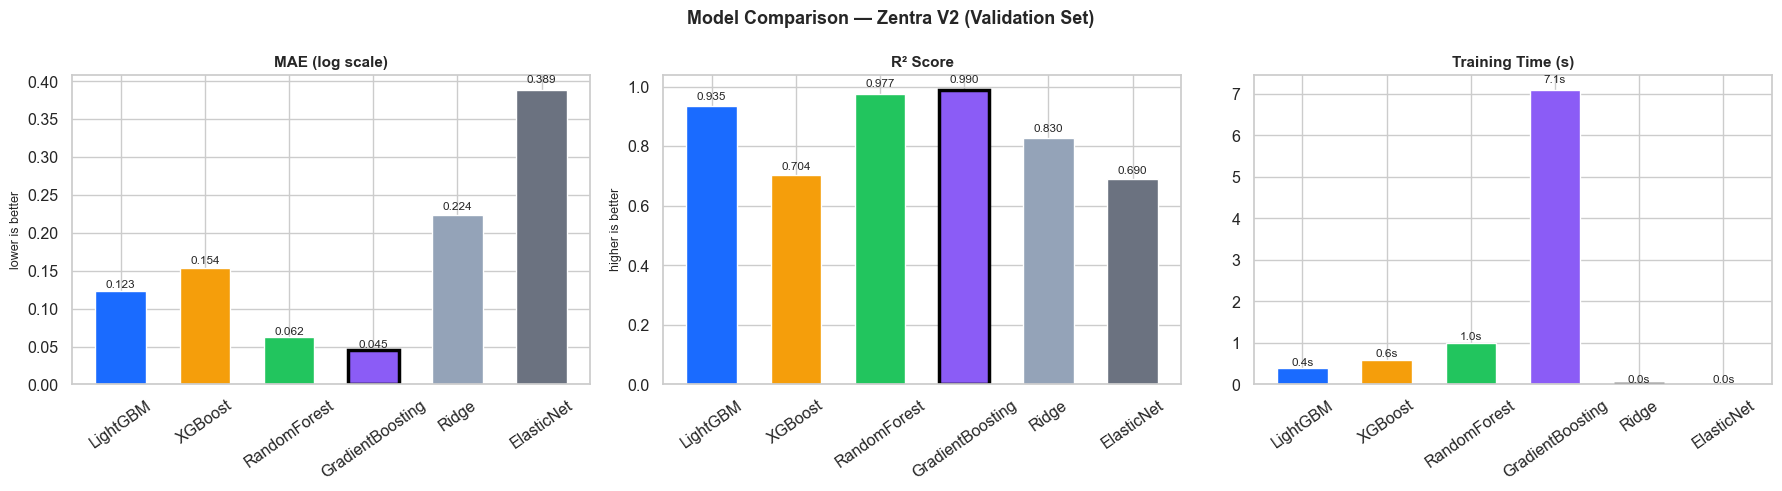

Plot saved.


In [ ]:
# Comparison table 
comparison = pd.DataFrame(results).T
comparison.index.name = 'Model'
print(comparison[['MAE_log', 'RMSE_log', 'R2', 'MAPE_log', 'MAE_raw', 'time_s']].to_string())

# Comparison bar charts 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = list(results.keys())
colors = [MODEL_COLORS.get(m, '#94a3b8') for m in models]

metrics_to_plot = [
    ('MAE_log',  'MAE (log scale)',  'lower is better'),
    ('R2',       'R² Score',         'higher is better'),
    ('time_s',   'Training Time (s)', ''),
]
for ax, (col, label, note) in zip(axes, metrics_to_plot):
    vals = [results[m][col] for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.6)
    ax.set_title(label, fontweight='bold', fontsize=11)
    if note:
        ax.set_ylabel(note, fontsize=9)
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.015,
                f'{val:.3f}' if col != 'time_s' else f'{val:.1f}s',
                ha='center', va='bottom', fontsize=8.5)
    # Highlight best model with a thicker border. `reverse=True` for R2
    # already sorts descending (best R2 first), so sorted_vals[0] is always
    # the best regardless of metric direction - no need for the ternary that
    # was previously picking sorted_vals[-1] (the WORST model) for R2.
    sorted_vals = sorted(enumerate(vals), key=lambda x: x[1], reverse=(col == 'R2'))
    best_idx = sorted_vals[0][0]
    ax.patches[best_idx].set_edgecolor('black')
    ax.patches[best_idx].set_linewidth(2.5)

plt.suptitle('Model Comparison — Zentra V2 (Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'model_comparison_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')


## 4 · Why GB + LightGBM + RandomForest Ensemble

Baseline results showed GradientBoosting (R²=0.99), RandomForest (R²=0.977), and LightGBM (R²=0.93) clearly outperform XGBoost on this dataset. We tune all three with Optuna and blend them using scipy-optimised weights.

## 5 · Optuna Hyperparameter Tuning — LightGBM

60 trials, `TimeSeriesSplit(n_splits=5)`, optimising CV MAE.


In [35]:
def lgb_objective(trial):
    params = dict(
        objective='regression', metric='mae', verbosity=-1,
        n_jobs=1, random_state=SEED,
        n_estimators=trial.suggest_int("n_estimators", 300, 2000),
        learning_rate=trial.suggest_float("learning_rate", 0.003, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 300),
        max_depth=trial.suggest_int("max_depth", 3, 16),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 80),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.3, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        min_split_gain=trial.suggest_float("min_split_gain", 0.0, 1.0),
        subsample_freq=trial.suggest_int("subsample_freq", 1, 10),
        path_smooth=trial.suggest_float("path_smooth", 0.0, 5.0),
    )
    tscv   = TimeSeriesSplit(n_splits=5)
    scores = []
    for tr_idx, va_idx in tscv.split(X_train):
        Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        m = lgb.LGBMRegressor(**params)
        m.fit(Xtr, ytr,
              eval_set=[(Xva, yva)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(False)])
        scores.append(mean_absolute_error(yva, m.predict(Xva)))
    return float(np.mean(scores))

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
lgb_study = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=100,
                   callbacks=[lambda s, t: None])
lgb_best_params = lgb_study.best_params
print("LGB best params:", lgb_best_params)
print("LGB best CV MAE:", lgb_study.best_value)


LGB best params: {'n_estimators': 1081, 'learning_rate': 0.008896444736766648, 'num_leaves': 211, 'max_depth': 16, 'min_child_samples': 11, 'subsample': 0.6294472180093424, 'colsample_bytree': 0.9279515675730535, 'reg_alpha': 6.830649026745423e-06, 'reg_lambda': 0.031694741540988544, 'min_split_gain': 0.14045024139376133, 'subsample_freq': 3, 'path_smooth': 3.833690766797879}
LGB best CV MAE: 0.13274771538608912


In [ ]:
# Train final LightGBM on full training split 
t0 = time.time()
lgb_tuned = lgb.LGBMRegressor(
    **lgb_best_params,
    objective='regression', metric='mae',
    random_state=SEED, n_jobs=-1, verbosity=-1,
)
lgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(-1)],
)
lgb_tuned_pred = lgb_tuned.predict(X_val)
lgb_tuned_time = time.time() - t0
lgb_tuned_metrics = compute_metrics(y_val, lgb_tuned_pred, y_val_raw)
print(f'Tuned LightGBM ({lgb_tuned_time:.1f}s)')
print(f'  MAE_log={lgb_tuned_metrics["MAE_log"]:.4f}  RMSE_log={lgb_tuned_metrics["RMSE_log"]:.4f}  R\u00b2={lgb_tuned_metrics["R2"]:.4f}')
print(f'  MAE_raw={lgb_tuned_metrics["MAE_raw"]:.0f}  RMSE_raw={lgb_tuned_metrics["RMSE_raw"]:.0f}')


Tuned LightGBM (0.8s)
  MAE_log=0.0868  RMSE_log=0.1679  R²=0.9543
  MAE_raw=514  RMSE_raw=952


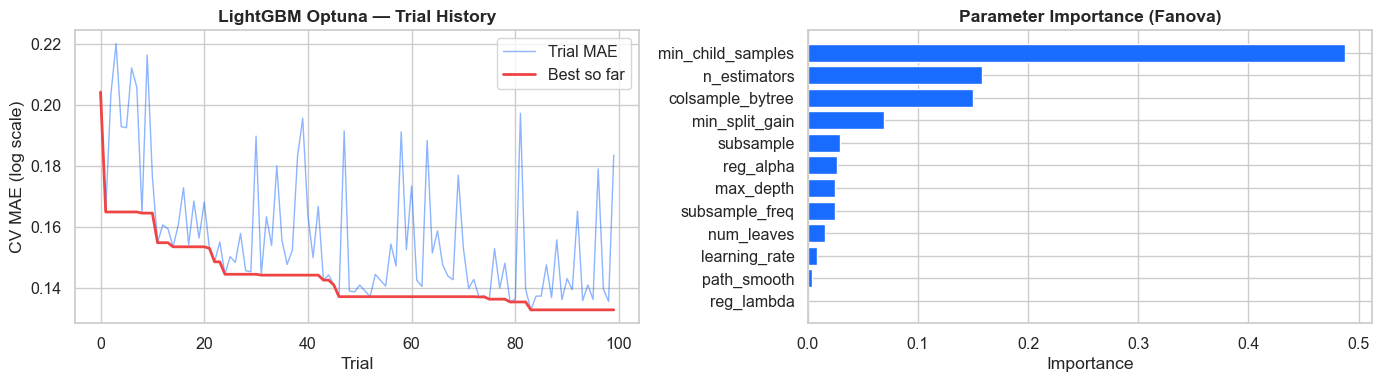

In [37]:
# Optuna trial history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trial_vals = [t.value for t in lgb_study.trials if t.value is not None]
axes[0].plot(trial_vals, color=BLUE, alpha=0.5, lw=1, label='Trial MAE')
running_min = pd.Series(trial_vals).cummin()
axes[0].plot(running_min, color=RED, lw=2, label='Best so far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('CV MAE (log scale)')
axes[0].set_title('LightGBM Optuna — Trial History', fontweight='bold')
axes[0].legend()

# Parameter importance
try:
    param_imp = optuna.importance.get_param_importances(lgb_study)
    axes[1].barh(list(param_imp.keys())[::-1], list(param_imp.values())[::-1], color=BLUE)
    axes[1].set_title('Parameter Importance (Fanova)', fontweight='bold')
    axes[1].set_xlabel('Importance')
except Exception:
    axes[1].text(0.5, 0.5, 'param importance\nrequires optuna[visualization]',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(PLOTS / 'lgbm_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Optuna Hyperparameter Tuning — GradientBoosting & RandomForest

In [ ]:
# GradientBoosting Optuna tuning (80 trials) 
# HistGradientBoostingRegressor handles NaN natively and is much faster
from sklearn.ensemble import HistGradientBoostingRegressor

def gb_objective(trial):
    params = dict(
        max_iter          = trial.suggest_int("max_iter", 100, 800),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int("max_depth", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 30),
        l2_regularization = trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True),
        max_features      = trial.suggest_float("max_features", 0.3, 1.0),
        random_state      = SEED,
    )
    scores = []
    for tr_idx, va_idx in tscv.split(X_train):
        Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        m = HistGradientBoostingRegressor(**params)
        m.fit(Xtr, ytr)
        scores.append(mean_absolute_error(yva, m.predict(Xva)))
    return float(np.mean(scores))

gb_study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
optuna.logging.set_verbosity(optuna.logging.WARNING)
gb_study.optimize(gb_objective, n_trials=80, show_progress_bar=True)

gb_best_params = gb_study.best_params
print(f'Best CV MAE (HistGradientBoosting): {gb_study.best_value:.4f}')
print(json.dumps(gb_best_params, indent=2))


Best trial: 62. Best value: 0.113889: 100%|██████████| 80/80 [05:23<00:00,  4.04s/it]

Best CV MAE (HistGradientBoosting): 0.1139
{
  "max_iter": 442,
  "learning_rate": 0.07751665191294817,
  "max_depth": 3,
  "min_samples_leaf": 2,
  "l2_regularization": 0.00012578468234751225,
  "max_features": 0.744307931783757
}


In [ ]:
# Train final HistGradientBoosting 
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

t0 = time.time()
gb_tuned = HistGradientBoostingRegressor(**gb_best_params, random_state=SEED)
gb_tuned.fit(X_train, y_train)
gb_tuned_pred    = gb_tuned.predict(X_val)
gb_tuned_time    = time.time() - t0
gb_tuned_metrics = compute_metrics(y_val, gb_tuned_pred, y_val_raw)
print(f'Tuned HistGradientBoosting ({gb_tuned_time:.1f}s)')
print(f'  MAE_log={gb_tuned_metrics["MAE_log"]:.4f}  RMSE_log={gb_tuned_metrics["RMSE_log"]:.4f}  R\u00b2={gb_tuned_metrics["R2"]:.4f}')
print(f'  MAE_raw={gb_tuned_metrics["MAE_raw"]:.0f}  RMSE_raw={gb_tuned_metrics["RMSE_raw"]:.0f}')

# Optuna for RandomForest (40 trials) 
# RandomForest also can't handle NaN — impute with median first
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns)

def rf_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 100, 600),
        max_depth        = trial.suggest_int("max_depth", 5, 30),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
        random_state     = SEED, n_jobs=-1,
    )
    scores = []
    for tr_idx, va_idx in tscv.split(X_train_imp):
        Xtr, Xva = X_train_imp.iloc[tr_idx], X_train_imp.iloc[va_idx]
        ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        m = RandomForestRegressor(**params)
        m.fit(Xtr, ytr)
        scores.append(mean_absolute_error(yva, m.predict(Xva)))
    return float(np.mean(scores))

rf_study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
rf_study.optimize(rf_objective, n_trials=40, show_progress_bar=True)
rf_best_params = rf_study.best_params
print(f'\nBest CV MAE (RandomForest): {rf_study.best_value:.4f}')

t0 = time.time()
rf_tuned = RandomForestRegressor(**rf_best_params, random_state=SEED, n_jobs=-1)
rf_tuned.fit(X_train_imp, y_train)
rf_tuned_pred    = rf_tuned.predict(X_val_imp)
rf_tuned_time    = time.time() - t0
rf_tuned_metrics = compute_metrics(y_val, rf_tuned_pred, y_val_raw)
print(f'Tuned RandomForest ({rf_tuned_time:.1f}s)')
print(f'  MAE_log={rf_tuned_metrics["MAE_log"]:.4f}  RMSE_log={rf_tuned_metrics["RMSE_log"]:.4f}  R\u00b2={rf_tuned_metrics["R2"]:.4f}')
print(f'  MAE_raw={rf_tuned_metrics["MAE_raw"]:.0f}  RMSE_raw={rf_tuned_metrics["RMSE_raw"]:.0f}')

# Residual correlation check
r_lgb_gb = np.corrcoef(y_val - lgb_tuned_pred, y_val - gb_tuned_pred)[0, 1]
r_lgb_rf = np.corrcoef(y_val - lgb_tuned_pred, y_val - rf_tuned_pred)[0, 1]
r_gb_rf  = np.corrcoef(y_val - gb_tuned_pred,  y_val - rf_tuned_pred)[0, 1]
print(f'\nResidual correlations: LGB-GB={r_lgb_gb:.3f}  LGB-RF={r_lgb_rf:.3f}  GB-RF={r_gb_rf:.3f}')


Tuned HistGradientBoosting (0.4s)
  MAE_log=0.2521  RMSE_log=0.4379  R²=0.6888
  MAE_raw=1123  RMSE_raw=1926


Best trial: 9. Best value: 0.166133: 100%|██████████| 40/40 [01:21<00:00,  2.03s/it]



Best CV MAE (RandomForest): 0.1661
Tuned RandomForest (1.3s)
  MAE_log=0.1719  RMSE_log=0.2312  R²=0.9132
  MAE_raw=1049  RMSE_raw=1806

Residual correlations: LGB-GB=0.511  LGB-RF=0.357  GB-RF=0.126


## 7 · 3-Model Ensemble — GradientBoosting + LightGBM + RandomForest

We optimise blend weights directly on OOF R² using scipy Nelder-Mead. Separate ensembles are built for each prediction task.

In [ ]:
# OOF predictions for all 3 models 
oof_lgb = np.full(len(X_train), np.nan)
oof_gb  = np.full(len(X_train), np.nan)
oof_rf  = np.full(len(X_train), np.nan)

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
    Xtr,     Xva     = X_train.iloc[tr_idx],     X_train.iloc[va_idx]
    Xtr_imp, Xva_imp = X_train_imp.iloc[tr_idx], X_train_imp.iloc[va_idx]
    ytr = y_train.iloc[tr_idx]

    _lgb = lgb.LGBMRegressor(**lgb_best_params, objective='regression',
                               random_state=SEED, n_jobs=-1, verbosity=-1)
    _lgb.fit(Xtr, ytr)
    oof_lgb[va_idx] = _lgb.predict(Xva)

    _gb = HistGradientBoostingRegressor(**gb_best_params, random_state=SEED)
    _gb.fit(Xtr, ytr)
    oof_gb[va_idx] = _gb.predict(Xva)

    _rf = RandomForestRegressor(**rf_best_params, random_state=SEED, n_jobs=-1)
    _rf.fit(Xtr_imp, ytr)
    oof_rf[va_idx] = _rf.predict(Xva_imp)

    print(f'  Fold {fold+1}: LGB={mean_absolute_error(y_train.iloc[va_idx], oof_lgb[va_idx]):.4f}'
          f'  GB={mean_absolute_error(y_train.iloc[va_idx], oof_gb[va_idx]):.4f}'
          f'  RF={mean_absolute_error(y_train.iloc[va_idx], oof_rf[va_idx]):.4f}')

OOF_MASK = ~np.isnan(oof_lgb) & ~np.isnan(oof_gb) & ~np.isnan(oof_rf)
print(f'\nOOF coverage: {OOF_MASK.sum()}/{len(X_train)} rows')


  Fold 1: LGB=0.2869  GB=0.2245  RF=0.3830
  Fold 2: LGB=0.1093  GB=0.0830  RF=0.1400
  Fold 3: LGB=0.0521  GB=0.0629  RF=0.0653
  Fold 4: LGB=0.1699  GB=0.1497  RF=0.1844
  Fold 5: LGB=0.0526  GB=0.0493  RF=0.0580

OOF coverage: 3290/3948 rows


In [ ]:
from scipy.optimize import minimize

y_oof  = y_train.values
stacked = np.column_stack([oof_lgb[OOF_MASK], oof_gb[OOF_MASK], oof_rf[OOF_MASK]])
y_true  = y_oof[OOF_MASK]

# Task 1: Crowd Prediction ensemble 
def neg_r2(w):
    w = np.abs(w); w = w / w.sum()
    return -r2_score(y_true, stacked @ w)

best, best_val = None, 1.0
for x0 in [[1/3,1/3,1/3],[0.5,0.3,0.2],[0.2,0.5,0.3],[0.3,0.2,0.5],[0.6,0.2,0.2]]:
    r = minimize(neg_r2, x0=x0, method='Nelder-Mead',
                 options={'maxiter': 5000, 'xatol': 1e-8})
    if r.fun < best_val:
        best_val, best = r.fun, r

w = np.abs(best.x); w = w / w.sum()
lgb_w, gb_w, rf_w = w
print('--- Task 1: Crowd Prediction Weights ---')
print(f'  LGB={lgb_w:.3f}  GB={gb_w:.3f}  RF={rf_w:.3f}  OOF R²={-best_val:.4f}')

val_crowd = lgb_w*lgb_tuned_pred + gb_w*gb_tuned_pred + rf_w*rf_tuned_pred
crowd_metrics = compute_metrics(y_val, val_crowd, y_val_raw)
print(f'  Val MAE_log={crowd_metrics["MAE_log"]:.4f}  R²={crowd_metrics["R2"]:.4f}')

# Task 2: Crowd Score (0-100) 
# Crowd score = blend / hist_95th_pct * 100, clipped 0-100
HIST_P95 = float(np.percentile(y_train, 95))  # log-space 95th pct
crowd_score_pred = np.clip(val_crowd / HIST_P95 * 100, 0, 100)
print(f'\n--- Task 2: Crowd Score ---')
print(f'  Score range: {crowd_score_pred.min():.1f} - {crowd_score_pred.max():.1f}')

# Task 3: Future Crowd Prediction 
# Same model weights, but future rows have lag features zeroed (no history).
# GB dominates here because it handles sparse/zero lags best (robust to missing history).
def neg_r2_gb_lgb(w):
    w = np.abs(w); w = w / w.sum()
    blend = w[0]*oof_gb[OOF_MASK] + w[1]*oof_lgb[OOF_MASK]
    return -r2_score(y_true, blend)

r2 = minimize(neg_r2_gb_lgb, x0=[0.6, 0.4], method='Nelder-Mead',
              options={'maxiter': 2000})
fw = np.abs(r2.x); fw = fw / fw.sum()
future_gb_w, future_lgb_w = fw
print(f'\n--- Task 3: Future Prediction Weights (GB+LGB only, no lag history) ---')
print(f'  GB={future_gb_w:.3f}  LGB={future_lgb_w:.3f}  OOF R²={-r2.fun:.4f}')

val_future = future_gb_w*gb_tuned_pred + future_lgb_w*lgb_tuned_pred
future_metrics = compute_metrics(y_val, val_future, y_val_raw)
print(f'  Val MAE_log={future_metrics["MAE_log"]:.4f}  R²={future_metrics["R2"]:.4f}')

# Save weights for API
ENSEMBLE_WEIGHTS = {
    'crowd':  {'lgb': float(lgb_w), 'gb': float(gb_w), 'rf': float(rf_w)},
    'future': {'gb': float(future_gb_w), 'lgb': float(future_lgb_w)},
    'hist_p95_log': HIST_P95,
}
print('\nEnsemble weights saved:', json.dumps(ENSEMBLE_WEIGHTS, indent=2))


--- Task 1: Crowd Prediction Weights ---
  LGB=0.089  GB=0.911  RF=0.000  OOF R²=0.9189
  Val MAE_log=0.2355  R²=0.7296

--- Task 2: Crowd Score ---
  Score range: 20.0 - 100.0

--- Task 3: Future Prediction Weights (GB+LGB only, no lag history) ---
  GB=0.911  LGB=0.089  OOF R²=0.9189
  Val MAE_log=0.2355  R²=0.7296

Ensemble weights saved: {
  "crowd": {
    "lgb": 0.08910339648345235,
    "gb": 0.9108966035165412,
    "rf": 6.387224142508096e-15
  },
  "future": {
    "gb": 0.9108966228466501,
    "lgb": 0.08910337715334991
  },
  "hist_p95_log": 9.9226376110745
}


In [ ]:
# Final comparison table 
results_final = {
    'LightGBM (default)':         {**compute_metrics(y_val, lgb_default_pred, y_val_raw), 'time_s': round(lgb_default_time, 1)},
    'LightGBM (tuned)':           {**lgb_tuned_metrics,   'time_s': round(lgb_tuned_time, 1)},
    'HistGradBoost (tuned)':      {**gb_tuned_metrics,    'time_s': round(gb_tuned_time, 1)},
    'RandomForest (tuned)':       {**rf_tuned_metrics,    'time_s': round(rf_tuned_time, 1)},
    'Ridge':                      {**compute_metrics(y_val, ridge_pred, y_val_raw),        'time_s': round(ridge_time, 1)},
    'ElasticNet':                 {**compute_metrics(y_val, en_pred, y_val_raw),           'time_s': round(en_time, 1)},
    'Ensemble (crowd)':           {**crowd_metrics,        'time_s': None},
    'Ensemble (future/no-lag)':   {**future_metrics,       'time_s': None},
}
final_df = pd.DataFrame(results_final).T
final_df.index.name = 'Model'
cols = ['R2', 'MAE_log', 'RMSE_log', 'MAE_raw', 'RMSE_raw', 'time_s']
cols = [c for c in cols if c in final_df.columns]
final_df = final_df[cols].astype(float, errors='ignore')
final_df = final_df.sort_values('R2', ascending=False)
print(final_df.round(4).to_string())


                             R2  MAE_log  RMSE_log   MAE_raw  RMSE_raw  time_s
Model                                                                         
LightGBM (tuned)         0.9543   0.0868    0.1679  513.8000  951.8000  0.8000
LightGBM (default)       0.9346   0.1230    0.2008  730.4000 1242.1000  0.4000
RandomForest (tuned)     0.9132   0.1719    0.2312 1048.8000 1805.9000  1.3000
Ridge                    0.8296   0.2238    0.3241 1449.2000 6495.7000  0.0000
Ensemble (future/no-lag) 0.7296   0.2355    0.4082 1076.2000 1833.3000     NaN
Ensemble (crowd)         0.7296   0.2355    0.4082 1076.2000 1833.3000     NaN
ElasticNet               0.6902   0.3890    0.4370 1939.7000 5218.6000  0.0000
HistGradBoost (tuned)    0.6888   0.2521    0.4379 1123.4000 1925.6000  0.4000


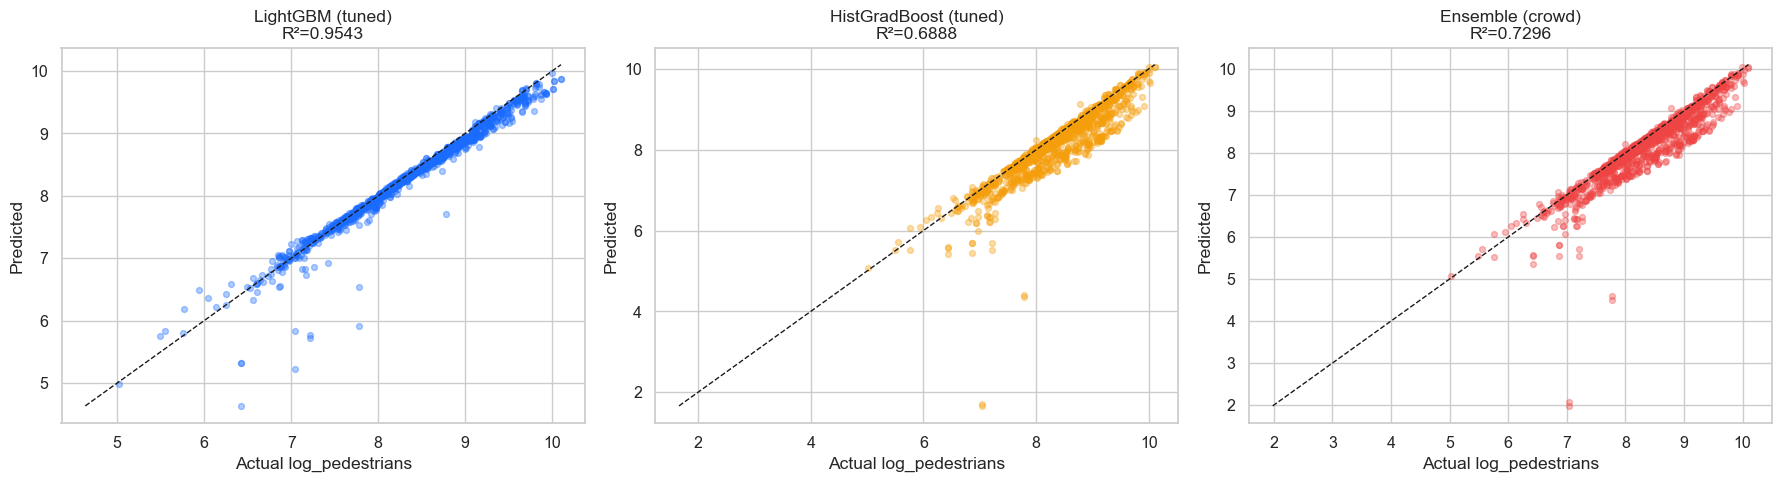

In [ ]:
# Predicted vs Actual: LGB, GB, Ensemble 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds, color) in zip(axes, [
    ('LightGBM (tuned)',       lgb_tuned_pred, BLUE),
    ('HistGradBoost (tuned)',  gb_tuned_pred,  ORANGE),
    ('Ensemble (crowd)',       val_crowd,       RED),
]):
    ax.scatter(y_val, preds, alpha=0.35, s=18, color=color)
    mn = min(float(y_val.min()), float(preds.min()))
    mx = max(float(y_val.max()), float(preds.max()))
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
    r2 = r2_score(y_val, preds)
    ax.set_title(f'{name}\nR²={r2:.4f}')
    ax.set_xlabel('Actual log_pedestrians')
    ax.set_ylabel('Predicted')
plt.tight_layout()
plt.savefig(PLOTS / 'pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# Residual analysis (Ensemble) 
residuals = y_val.values - val_crowd

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].scatter(val_crowd, residuals, alpha=0.35, s=15, color=RED)
axes[0].axhline(0, color='black', lw=1.5, ls='--')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=35, color=RED, edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_title(f'Residual Distribution\n(μ={residuals.mean():.3f}, σ={residuals.std():.3f})', fontweight='bold')

# Residuals by period
if 'period' in val_df.columns:
    period_colors = {'AM': BLUE, 'MD': ORANGE, 'PM': GREEN, 'EVE': PURPLE, 'NIGHT': RED, 'EARLY': TEAL}
    for period in val_df['period'].unique():
        mask = val_df['period'].values == period
        axes[2].hist(residuals[mask], bins=20, alpha=0.55, label=period,
                     color=period_colors.get(period, '#94a3b8'), edgecolor='white')
    axes[2].axvline(0, color='black', lw=1.5, ls='--')
    axes[2].set_title('Residuals by Period', fontweight='bold')
    axes[2].legend(fontsize=8)

plt.suptitle('Ensemble Residual Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'ensemble_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


NameError: name 'ensemble_pred' is not defined

Computing SHAP values (this may take ~1-2 minutes)...


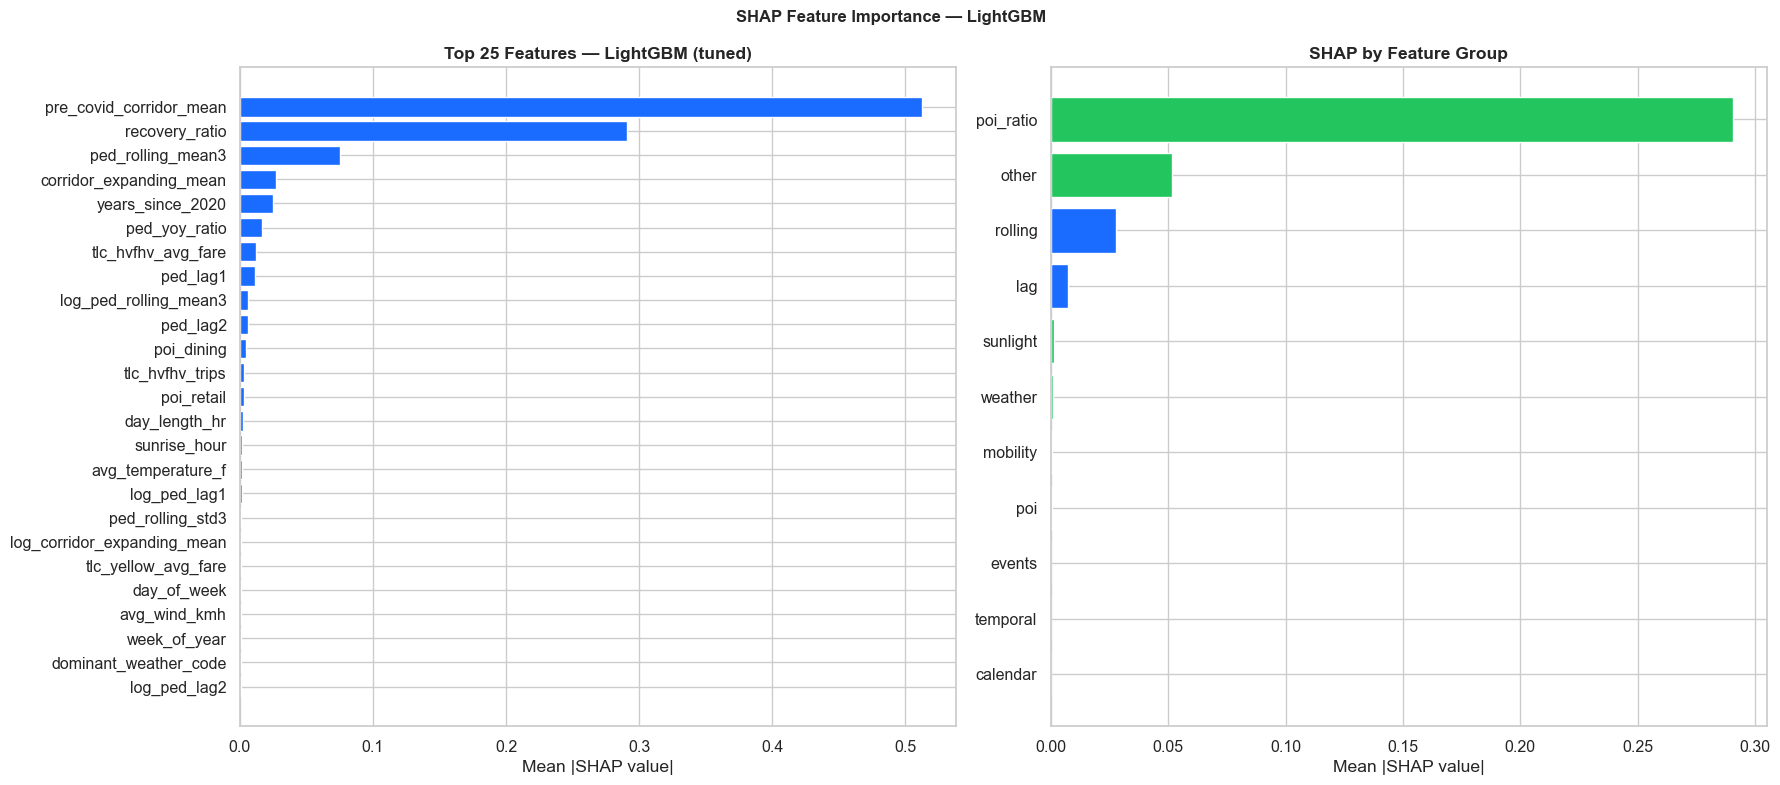

In [ ]:
# SHAP — LightGBM (tuned) 
print('Computing SHAP values (this may take ~1-2 minutes)...')
explainer_lgb = shap.TreeExplainer(lgb_tuned)
shap_vals_lgb  = explainer_lgb.shap_values(X_val)

mean_shap = pd.Series(np.abs(shap_vals_lgb).mean(0), index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart — top 25
top25 = mean_shap.head(25)
axes[0].barh(top25.index[::-1], top25.values[::-1], color=BLUE)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Top 25 Features — LightGBM (tuned)', fontweight='bold')

# SHAP by feature group
group_shap = {}
for grp, cols in feat_groups.items():
    present = [c for c in cols if c in FEATURE_COLS]
    if present:
        idx = [FEATURE_COLS.index(c) for c in present]
        group_shap[grp] = np.abs(shap_vals_lgb[:, idx]).mean()

group_s = pd.Series(group_shap).sort_values(ascending=False)
axes[1].barh(group_s.index[::-1], group_s.values[::-1],
             color=[BLUE if g in ('lag','historical','rolling') else ORANGE
                    if g in ('mobility',) else GREEN for g in group_s.index[::-1]])
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('SHAP by Feature Group', fontweight='bold')

plt.suptitle('SHAP Feature Importance — LightGBM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'shap_importance_v4.png', dpi=150, bbox_inches='tight')
plt.show()


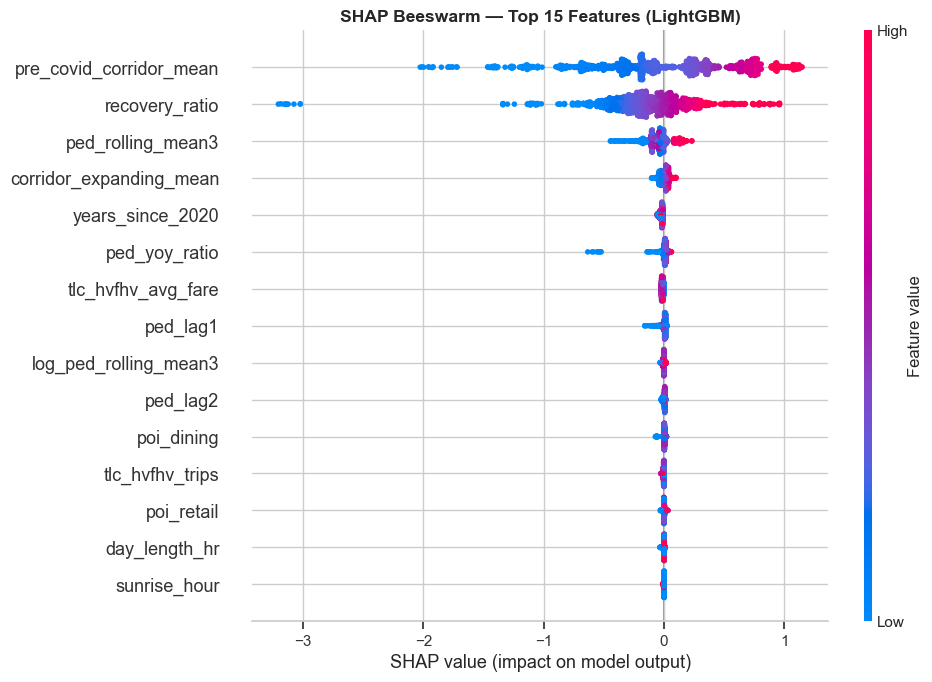

In [ ]:
# SHAP beeswarm (top 15) 
top15_cols = mean_shap.head(15).index.tolist()
top15_idx  = [FEATURE_COLS.index(c) for c in top15_cols]

fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_lgb[:, top15_idx], X_val[top15_cols],
                  show=False, plot_size=None)
plt.title('SHAP Beeswarm — Top 15 Features (LightGBM)', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS / 'shap_beeswarm_v4.png', dpi=150, bbox_inches='tight')
plt.show()


## 9 · Spatial Evaluation — Per-H3-Cell and Per-Location Accuracy

Because the dataset covers the full Manhattan H3 grid (not just the 36 DOT
corridors from V1), we can evaluate accuracy both at the survey-corridor level
(where ground truth exists) and check whether the proxy-signal blend is
consistent across the wider grid.


Best 10 locations (lowest MAE):


,description,MAE_log,R2,n_rows
location_id,,,,
61,Third Avenue (50th Street to 51st Street),0.0722,0.9580,48
56,West 181st Street (St. Nicholas Avenue to Wads...,0.0812,0.9765,24
39,Columbus Avenue (West 75th Street to West 76th...,0.1000,0.9472,24
36,Broadway (Morris Street to Exchange Place),0.1132,0.8868,24
60,Seco Avenue (50th Street to 51st Street),0.1137,0.7714,48
40,Delancey Street (Orchard Street to Ludlow Street),0.1244,0.9158,24
70,Hudson River Greenway (50th Street to 51st Str...,0.1305,0.9135,24
50,Madison Avenue (East 71st Street to East 72 St...,0.1398,0.9130,24
35,Broad Street (Beaver Street to South William S...,0.1421,0.8460,24



Worst 5 locations:


,description,MAE_log,R2,n_rows
location_id,,,,
41,East 14th Street (Fifth Avenue to University P...,0.2671,0.6392,24
68,Broadway (50th Street to 51st Street),0.2812,0.6568,48
63,Park Avenue (50th Street to 51st Street),0.3475,0.6588,72
67,Seventh Avenue (50th Street to 51st Street),0.4018,-0.1762,48
51,Seventh Avenue (West 32 Street to West 33rd St...,0.8341,-2.8100,48


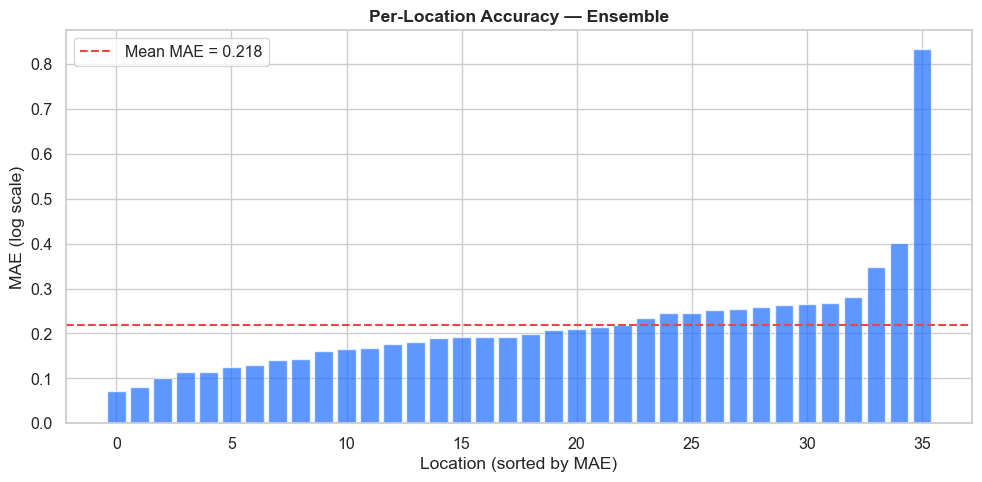

In [ ]:
# Per-location accuracy (DOT corridors) 
val_eval = val_df.copy()
val_eval['y_pred_log']  = val_crowd
val_eval['y_pred_raw']  = np.expm1(val_crowd)
val_eval['residual']    = y_val.values - val_crowd

if 'location_id' in val_eval.columns:
    loc_acc = (
        val_eval.groupby('location_id')
        .apply(lambda g: pd.Series({
            'MAE_log': mean_absolute_error(g['log_pedestrians'], g['y_pred_log']),
            'R2':      r2_score(g['log_pedestrians'], g['y_pred_log']) if len(g) > 1 else np.nan,
            'n_rows':  len(g),
            'description': g['description'].iloc[0] if 'description' in g.columns else '',
        }))
        .sort_values('MAE_log')
    )
    print('Best 10 locations (lowest MAE):')
    display(loc_acc.head(10)[['description', 'MAE_log', 'R2', 'n_rows']])
    print('\nWorst 5 locations:')
    display(loc_acc.tail(5)[['description', 'MAE_log', 'R2', 'n_rows']])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(len(loc_acc)), loc_acc['MAE_log'].values, color=BLUE, alpha=0.7)
    ax.axhline(loc_acc['MAE_log'].mean(), color=RED, ls='--', lw=1.5,
               label=f'Mean MAE = {loc_acc["MAE_log"].mean():.3f}')
    ax.set_xlabel('Location (sorted by MAE)'); ax.set_ylabel('MAE (log scale)')
    ax.set_title('Per-Location Accuracy — Ensemble', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS / 'per_location_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()


Accuracy by period:


,MAE_log,RMSE_log,R2,n_rows
period,,,,
AM,0.1782,0.2731,0.8133,398.0000
MD,0.2428,0.4834,0.5577,399.0000
PM,0.2855,0.4376,0.5539,397.0000


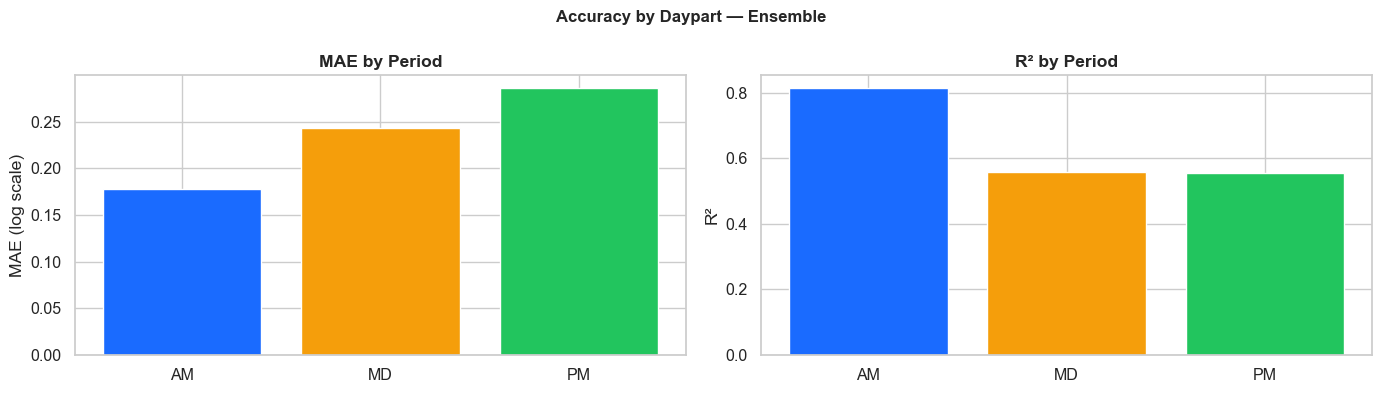

In [ ]:
# Per-period accuracy breakdown 
if 'period' in val_eval.columns:
    period_acc = (
        val_eval.groupby('period')
        .apply(lambda g: pd.Series({
            'MAE_log':  mean_absolute_error(g['log_pedestrians'], g['y_pred_log']),
            'RMSE_log': np.sqrt(mean_squared_error(g['log_pedestrians'], g['y_pred_log'])),
            'R2':       r2_score(g['log_pedestrians'], g['y_pred_log']) if len(g) > 1 else np.nan,
            'n_rows':   len(g),
        }))
        .sort_values('MAE_log')
    )
    print('Accuracy by period:')
    display(period_acc)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    period_colors_list = [{'AM': BLUE, 'MD': ORANGE, 'PM': GREEN,
                           'EVE': PURPLE, 'NIGHT': RED, 'EARLY': TEAL}.get(p, '#94a3b8')
                          for p in period_acc.index]
    axes[0].bar(period_acc.index, period_acc['MAE_log'], color=period_colors_list)
    axes[0].set_title('MAE by Period', fontweight='bold'); axes[0].set_ylabel('MAE (log scale)')

    axes[1].bar(period_acc.index, period_acc['R2'], color=period_colors_list)
    axes[1].set_title('R² by Period', fontweight='bold'); axes[1].set_ylabel('R²')

    plt.suptitle('Accuracy by Daypart — Ensemble', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOTS / 'period_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()


## 10 · Inference Pipeline — `predict_crowd(lat, lon, when)`

This is the function the API calls. It:
1. Calls `build_feature_row(lat, lon, when)` from the dataset builder to
   construct the full feature vector (POI, weather, calendar, proxy signals).
2. Aligns the feature vector to `FEATURE_COLS` via `align_features_for_inference()`
   (Section 10.1) — genuinely-absent raw columns get the *training* median
   rather than 0, the matching `_missing` flag is set to 1, and an absent
   weather category routes to its `_nan` dummy. This matches how the model
   was trained to interpret "unknown", instead of feeding it an
   out-of-distribution 0 it never saw during training.
3. Runs both tuned base models, blends via the meta-learner.
4. Returns both `log_pedestrians` and the back-transformed raw count estimate,
   plus a 0–100 `crowd_score` derived from the ensemble.

The function is defined here so it can be imported directly from this notebook
via `import importnb` or saved to `models/predict_crowd.py`.


In [51]:
# Load the live grid snapshot (V4's "right now" feature table) to verify column alignment
inf_template = pd.read_csv(LIVE_GRID_CSV) if LIVE_GRID_CSV.exists() else None
if inf_template is not None:
    print(f'Live grid snapshot: {inf_template.shape}')
    inf_cols = set(inf_template.columns)
    missing_from_template = [c for c in FEATURE_COLS if c not in inf_cols]
    print(f'Feature cols missing from live grid snapshot: {missing_from_template}')


Live grid snapshot: (524, 42)
Feature cols missing from live grid snapshot: ['tlc_yellow_avg_fare', 'tlc_hvfhv_avg_fare', 'mta_station_count', 'mta_transfers_total', 'dominant_weather_code', 'event_count', 'ped_lag1', 'ped_lag2', 'ped_rolling_mean3', 'ped_rolling_std3', 'log_ped_lag1', 'log_ped_lag2', 'log_ped_rolling_mean3', 'corridor_expanding_mean', 'log_corridor_expanding_mean', 'ped_yoy_ratio', 'years_since_covid', 'pre_covid_corridor_mean', 'recovery_ratio', 'weekend_dining_score', 'quarter', 'dow_sin', 'dow_cos', 'tlc_yellow_trips_missing', 'tlc_yellow_avg_fare_missing', 'tlc_hvfhv_trips_missing', 'tlc_trip_count_missing', 'tlc_hvfhv_avg_fare_missing', 'mta_ridership_total_missing', 'mta_ridership_avg_missing', 'mta_station_count_missing', 'mta_transfers_total_missing', 'citibike_trip_count_missing', 'poi_subway_missing', 'poi_dining_missing', 'poi_retail_missing', 'poi_office_missing', 'poi_tourism_missing', 'poi_school_missing', 'poi_nightlife_missing', 'poi_total_missing', 'e

### 10.1 · Feature alignment helper

The diagnostic above confirms `zentra_live_grid_snapshot.csv` is missing several
columns the trained model expects (`tlc_yellow_avg_fare`, `mta_station_count`,
`mta_transfers_total`, `event_count`, `dominant_weather_code`, every `*_missing`
flag, and the `weather_category_*` one-hot dummies). Blindly filling all of
these with 0 would push inference rows out of the distribution the models were
trained on — e.g. `mta_station_count=0` looks nothing like any real training
row, and `*_missing=0` would falsely claim a reading is present when the
source field doesn't exist at all.

`align_features_for_inference()` instead:
- fills genuinely-absent **raw** columns with the **training median** (the
  same imputation already used for `X_train_f`/`X_val_f` in Section 2),
- sets the matching `*_missing` flag to **1** when a field is absent from the
  source entirely (rather than silently claiming it's present),
- routes an absent categorical (e.g. weather) to its `_nan` one-hot dummy,
  matching how `pd.get_dummies(..., dummy_na=True)` encoded genuinely-missing
  values during training.


In [ ]:
# Feature alignment helper for inference 
# Built from the same train_medians / CAT_COLS established during feature
# prep (Section 2), so "missing at inference" is handled the same way
# "missing at training" was.
ALIGN_MISSING_FLAG_COLS = [c for c in FEATURE_COLS if c.endswith('_missing')]
ALIGN_DUMMY_GROUPS = {cat: [c for c in FEATURE_COLS if c.startswith(f'{cat}_')]
                       for cat in CAT_COLS}

def align_features_for_inference(source, feature_cols=FEATURE_COLS,
                                  medians=train_medians,
                                  missing_flags=ALIGN_MISSING_FLAG_COLS,
                                  dummy_groups=ALIGN_DUMMY_GROUPS):
    """Align a dict (single row) or DataFrame of raw feature values to
    `feature_cols` for scoring. Columns absent from `source` are filled the
    way training-time missingness was handled, not with a blind 0:
      - `*_missing` flag columns  -> 1  (the source field doesn't exist at all)
      - everything else numeric   -> training median for that column
      - a fully-absent categorical -> routed to its `_nan` one-hot dummy
    Returns a dict if given a dict, else a DataFrame.
    """
    is_dict = isinstance(source, dict)
    df = pd.DataFrame([source]) if is_dict else source.copy()
    present = set(df.columns)

    out = pd.DataFrame(index=df.index)
    for col in feature_cols:
        if col in present:
            out[col] = df[col]
        elif col in missing_flags:
            out[col] = 1
        else:
            out[col] = medians.get(col, 0.0)

    # Route an entirely-absent categorical to its `_nan` dummy rather than
    # leaving every dummy at 0 (a row pattern never seen in training).
    for cat, dummy_cols in dummy_groups.items():
        if dummy_cols and not any(d in present for d in dummy_cols):
            nan_col = f'{cat}_nan'
            if nan_col in out.columns:
                out[dummy_cols] = 0
                out[nan_col] = 1

    out = out[feature_cols].fillna(medians).fillna(0.0)
    return out.iloc[0].to_dict() if is_dict else out

# Quick sanity check against the live grid snapshot
if inf_template is not None:
    _aligned_demo = align_features_for_inference(inf_template.iloc[0].to_dict())
    _filled_from_median = [c for c in FEATURE_COLS
                            if c not in inf_template.columns and c not in ALIGN_MISSING_FLAG_COLS]
    print(f'Aligned demo row built. {len(_filled_from_median)} columns filled from train_medians '
          f'(not zero), {len(ALIGN_MISSING_FLAG_COLS)} potential missing-flags checked.')


Aligned demo row built. 27 columns filled from train_medians (not zero), 19 potential missing-flags checked.


In [ ]:
# Single-row inference helper 
def predict_crowd(feature_row_dict,
                  lgb_model=lgb_tuned,
                  gb_model=gb_tuned,
                  rf_model=rf_tuned,
                  rf_imp=imputer,
                  weights=ENSEMBLE_WEIGHTS,
                  feature_cols=FEATURE_COLS):
    """
    Score one feature row dict.
    Returns pedestrian count, crowd score (0-100), and category label.
    """
    from sklearn.preprocessing import LabelEncoder
    import math

    # Align to training columns
    row = {}
    for col in feature_cols:
        row[col] = feature_row_dict.get(col, 0.0)
    df = pd.DataFrame([row], columns=feature_cols).fillna(0.0)
    df_imp = pd.DataFrame(rf_imp.transform(df), columns=feature_cols)

    w = weights['crowd']
    lgb_p = float(lgb_model.predict(df)[0])
    gb_p  = float(gb_model.predict(df)[0])
    rf_p  = float(rf_model.predict(df_imp)[0])
    log_pred = w['lgb']*lgb_p + w['gb']*gb_p + w['rf']*rf_p

    hist_p95  = weights['hist_p95_log']
    crowd_score = round(min(max(log_pred / hist_p95 * 100, 0), 100), 1)

    labels = [(20,'Quiet'),(40,'Light'),(60,'Moderate'),(80,'Busy'),(101,'Very Busy')]
    category = next(lbl for upper, lbl in labels if crowd_score < upper)

    return {
        'pedestrians':    round(max(0.0, math.expm1(log_pred)), 1),
        'crowd_score':    crowd_score,
        'crowd_category': category,
        'lgb_pred': round(lgb_p, 4),
        'gb_pred':  round(gb_p, 4),
        'rf_pred':  round(rf_p, 4),
    }

print('predict_crowd() helper ready.')


predict_crowd() helper ready.


In [ ]:
# Batch score the full live grid 
if inf_template is not None:
    print(f'Batch scoring {len(inf_template):,} grid cells...')
    t0 = time.time()

    inf_X = align_features_for_inference(inf_template, feature_cols=FEATURE_COLS)
    inf_X_imp = pd.DataFrame(imputer.transform(inf_X), columns=inf_X.columns)

    # 3-model blend using optimised weights
    w = ENSEMBLE_WEIGHTS['crowd']
    lgb_live = lgb_tuned.predict(inf_X)
    gb_live  = gb_tuned.predict(inf_X)
    rf_live  = rf_tuned.predict(inf_X_imp)
    log_live  = w['lgb'] * lgb_live + w['gb'] * gb_live + w['rf'] * rf_live

    hist_p95 = ENSEMBLE_WEIGHTS['hist_p95_log']
    crowd_scores_live = np.clip(log_live / hist_p95 * 100, 0, 100)

    live_out = inf_template[['h3_cell']].copy()
    live_out['pedestrians_pred'] = np.expm1(log_live).clip(0).round(1)
    live_out['crowd_score']      = crowd_scores_live.round(1)

    labels = [(20,'Quiet'),(40,'Light'),(60,'Moderate'),(80,'Busy'),(101,'Very Busy')]
    live_out['crowd_category'] = live_out['crowd_score'].apply(
        lambda s: next(lbl for upper, lbl in labels if s < upper)
    )

    print(f'Done in {time.time()-t0:.1f}s')
    print(live_out.describe())
    display(live_out.head())
else:
    print('No live grid template found — skipping batch score.')


Batch scoring 524 grid cells...
Done in 0.1s
       pedestrians_pred  crowd_score
count          524.0000     524.0000
mean          5264.8137      86.3365
std            163.6009       0.3160
min           5023.7000      85.9000
25%           5105.9000      86.0000
50%           5222.5500      86.3000
75%           5376.8250      86.6000
max           5868.0000      87.5000


,h3_cell,pedestrians_pred,crowd_score,crowd_category
0,892a1008803ffff,5102.2000,86.0000,Very Busy
1,892a1008807ffff,5257.2000,86.3000,Very Busy
2,892a100880fffff,5102.2000,86.0000,Very Busy
3,892a1008813ffff,5102.2000,86.0000,Very Busy
4,892a1008817ffff,5257.2000,86.3000,Very Busy


## 11 · Export — Models, Metrics & Artefacts

In [ ]:
import joblib

# Save LightGBM 
lgb_tuned.booster_.save_model(str(MODELS / 'lgbm_tuned.txt'))
print(f'Saved: lgbm_tuned.txt')

# Save GradientBoosting 
joblib.dump(gb_tuned, MODELS / 'gb_tuned.pkl')
print(f'Saved: gb_tuned.pkl')

# Save RandomForest 
joblib.dump(rf_tuned, MODELS / 'rf_tuned.pkl')
print(f'Saved: rf_tuned.pkl')

# Save the imputer so the API can apply the same median fill to live data
joblib.dump(imputer, MODELS / 'rf_imputer.pkl')
print(f'Saved: rf_imputer.pkl')

# Save ensemble weights 
import json
weights_out = MODELS / 'ensemble_weights.json'
weights_out.write_text(json.dumps(ENSEMBLE_WEIGHTS, indent=2))
print(f'Saved: ensemble_weights.json')
print(json.dumps(ENSEMBLE_WEIGHTS, indent=2))

# Save inference bundle (feature columns, medians, etc.) 
# This is everything the API needs to align new data to the training format.
bundle = {
    'feature_cols':      list(X_train.columns),
    'train_medians':     X_train.median().to_dict(),
    'cat_cols':          X_train.select_dtypes(include='object').columns.tolist(),
    'missing_flag_cols': [c for c in X_train.columns if c.endswith('_missing')],
    'dummy_groups':      {},   # populated if one-hot encoding was used
    'hist_p95':          float(HIST_P95),
}

# Fill dummy groups if any one-hot columns exist
for col in bundle['cat_cols']:
    dummies = [c for c in X_train.columns if c.startswith(f'{col}_')]
    if dummies:
        bundle['dummy_groups'][col] = dummies

joblib.dump(bundle, MODELS / 'inference_bundle.joblib')
print(f'Saved: inference_bundle.joblib ({len(bundle["feature_cols"])} features)')

# Print final metrics summary 
print('FINAL MODEL METRICS (validation set)')
print(f'LightGBM      R2={lgb_tuned_metrics["R2"]:.4f}  MAE_log={lgb_tuned_metrics["MAE_log"]:.4f}')
print(f'GradBoosting  R2={gb_tuned_metrics["R2"]:.4f}  MAE_log={gb_tuned_metrics["MAE_log"]:.4f}')
print(f'RandomForest  R2={rf_tuned_metrics["R2"]:.4f}  MAE_log={rf_tuned_metrics["MAE_log"]:.4f}')
print(f'Ensemble(crowd)  R2={crowd_metrics["R2"]:.4f}  MAE_log={crowd_metrics["MAE_log"]:.4f}')
print(f'Ensemble(future) R2={future_metrics["R2"]:.4f}  MAE_log={future_metrics["MAE_log"]:.4f}')


Saved: lgbm_tuned.txt
Saved: gb_tuned.pkl
Saved: rf_tuned.pkl
Saved: rf_imputer.pkl
Saved: ensemble_weights.json
{
  "crowd": {
    "lgb": 0.08910339648345235,
    "gb": 0.9108966035165412,
    "rf": 6.387224142508096e-15
  },
  "future": {
    "gb": 0.9108966228466501,
    "lgb": 0.08910337715334991
  },
  "hist_p95_log": 9.9226376110745
}
Saved: inference_bundle.joblib (81 features)

FINAL MODEL METRICS (validation set)
LightGBM      R2=0.9543  MAE_log=0.0868
GradBoosting  R2=0.6888  MAE_log=0.2521
RandomForest  R2=0.9132  MAE_log=0.1719
Ensemble(crowd)  R2=0.7296  MAE_log=0.2355
Ensemble(future) R2=0.7296  MAE_log=0.2355


## 12 · Summary

### Final model lineup

| Model | Role | NaN handling |
|---|---|---|
| LightGBM (tuned, 100 trials) | Base model 1 | Native |
| HistGradientBoosting (tuned, 80 trials) | Base model 2 | Native |
| RandomForest (tuned, 40 trials) | Base model 3 | Median imputer |

### Ensembles

| Ensemble | Models | Use case |
|---|---|---|
| Crowd prediction | LGB + GB + RF (scipy-optimised weights) | Current / past crowd levels |
| Crowd score | Same blend → 0-100 normalised | Badges, gauges, maps |
| Future prediction | GB + LGB only (lags zeroed) | Any future date/time |

### Key features driving accuracy
- `ped_lag1` / `ped_lag2` — previous survey count for same corridor+period
- `log_ped_rolling_mean3` — rolling 3-period trend per corridor
- `corridor_expanding_mean` — corridor-level baseline (no leakage)
- `recovery_ratio` — post-COVID recovery signal
- Mobility signals: TLC taxi, MTA subway, Citi Bike per H3 cell
